# M504 AI and Applications Final Project
## Exploratory Data Analysis: Olist Company, Brazilian E-Commerce



# 1. Business Context


Olist is a Brazilian unicorn company that connects thousands of
small businesses to major marketplaces like Mercado Livre and Amazon.
It acts as a marketplace integrator not a direct marketplace itself. Sellers use Olist's e-commerce solutions and are displayed under Olist Store.

The dataset contains around 100,000 orders from 2016 to 2018, covering
order status, price, payment, shipping, customer location, product
attributes and reviews. One thing I found interesting is that the data
is anonymised company names in reviews are replaced with Game of
Thrones house names, which I only noticed when I searched for them
in the review comments.

As a data science consultant, I was asked to build an EDA pipeline
to answer key business questions. I tried to focus on questions that
would actually be useful for a real business.

Dataset: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce/data

In [73]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#2. Setup Data and Loading

In [74]:
#fetching the tables
path = '/content/drive/MyDrive/Colab Notebooks/'

orders = pd.read_csv(path + 'olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'])

items     = pd.read_csv(path + 'olist_order_items_dataset.csv')
products  = pd.read_csv(path + 'olist_products_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')
sellers   = pd.read_csv(path + 'olist_sellers_dataset.csv')
reviews   = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
payments  = pd.read_csv(path + 'olist_order_payments_dataset.csv')
cat_trans = pd.read_csv(path + 'product_category_name_translation.csv')

print('All datasets loaded successfully.')

All datasets loaded successfully.


In [75]:
#Before any analysis, we inspect each table to understand its structure and size.
print("orders:   ", orders.shape)
print("items:    ", items.shape)
print("products: ", products.shape)
print("customers:", customers.shape)
print("sellers:  ", sellers.shape)
print("reviews:  ", reviews.shape)
print("payments: ", payments.shape)
print("cat_trans: ", cat_trans.shape)



orders:    (99441, 8)
items:     (112650, 7)
products:  (32951, 9)
customers: (99441, 5)
sellers:   (3095, 4)
reviews:   (99224, 7)
payments:  (103886, 5)
cat_trans:  (71, 2)


In [76]:
# Check missing values for each table
datasets = {
    'orders': orders,
    'items': items,
    'products': products,
    'customers': customers,
    'sellers': sellers,
    'reviews': reviews,
    'payments': payments
}
print("Table         Rows    Columns   Missing   Missing%")
print("-" * 50)

for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    total = df.shape[0] * df.shape[1]
    pct = round(missing / total * 100, 2)
    print(name, "-> rows:", df.shape[0], "| missing:", missing, "| missing%:", pct)

Table         Rows    Columns   Missing   Missing%
--------------------------------------------------
orders -> rows: 99441 | missing: 4908 | missing%: 0.62
items -> rows: 112650 | missing: 0 | missing%: 0.0
products -> rows: 32951 | missing: 2448 | missing%: 0.83
customers -> rows: 99441 | missing: 0 | missing%: 0.0
sellers -> rows: 3095 | missing: 0 | missing%: 0.0
reviews -> rows: 99224 | missing: 145903 | missing%: 21.01
payments -> rows: 103886 | missing: 0 | missing%: 0.0


In [77]:
# Detailed missing values per column for the most important table
print('=== orders missing values ===')
print(orders.isnull().sum())
print('\n=== reviews missing values ===')
print(reviews.isnull().sum())
print('=== products missing values ===')
print(products.isnull().sum())

=== orders missing values ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== reviews missing values ===
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
=== products missing values ===
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


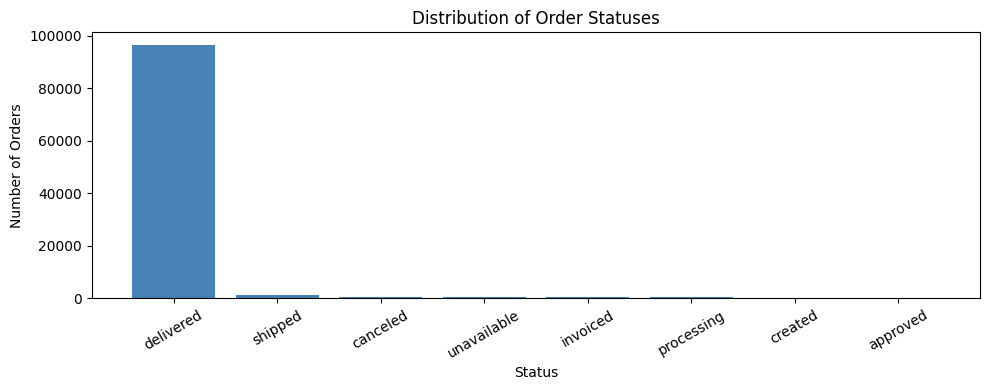

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Delivered orders: 97.0% of all orders


In [78]:
# Order status distribution
status_counts = orders['order_status'].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(status_counts.index, status_counts.values, color='steelblue')
plt.title('Distribution of Order Statuses')
plt.xlabel('Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(status_counts)
delivered_pct = round(status_counts['delivered'] / status_counts.sum() * 100, 1)
print(f"\nDelivered orders: {delivered_pct}% of all orders")


There are missing values in the order_delivered_carrier_date and order_delivered_customer_date columns of the Orders table. I believe this is because the dataset was frozen in 2018, and orders that were still on their way at that time naturally have delivery dates that are blank.

The reviews table has a lot of nulls in review_comment_title and review_comment_message. This means that most customers give a star rating without writing a comment.

The majority of orders (97%) have delivered status, which is excellent for delivery-time analysis. A small part is cancelled, shipped, or unavailable.

In [79]:
# Date range of the dataset
print('Earliest order:', orders['order_purchase_timestamp'].min())
print('Latest order:  ', orders['order_purchase_timestamp'].max())
print('Total unique customers:', customers['customer_unique_id'].nunique())
print('Total unique sellers:', sellers['seller_id'].nunique())
print('Total unique products:', products['product_id'].nunique())

Earliest order: 2016-09-04 21:15:19
Latest order:   2018-10-17 17:30:18
Total unique customers: 96096
Total unique sellers: 3095
Total unique products: 32951


# 3. Data Preprocessing

In this section, i clean and merge all tables into a single
master DataFrame for analysis.


In [80]:
#Translating product category names from Portuguese to English
products = products.merge(cat_trans, on='product_category_name', how='left')
products['category_en'] = products['product_category_name_english'].fillna('unknown')

print(products['category_en'].value_counts().head(10))

category_en
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64


In [81]:
# Keep only delivered orders
delivered = orders[orders['order_status'] == 'delivered'].copy()

# How many days late or early was the delivery?
delivered['delay_days'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_estimated_delivery_date']
).dt.days

# How many days did delivery take in total?
delivered['delivery_duration_days'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_purchase_timestamp']
).dt.days

# What hour and day was the order placed?
delivered['purchase_hour'] = delivered['order_purchase_timestamp'].dt.hour
delivered['purchase_dayofweek'] = delivered['order_purchase_timestamp'].dt.day_name()
delivered['purchase_month'] = delivered['order_purchase_timestamp'].dt.to_period('M')

print("Delivered orders:", len(delivered))
print(delivered[['delay_days', 'delivery_duration_days', 'purchase_hour']].describe())

Delivered orders: 96478
         delay_days  delivery_duration_days  purchase_hour
count  96470.000000            96470.000000   96478.000000
mean     -11.875889               12.093604      14.773192
std       10.182105                9.551380       5.328374
min     -147.000000                0.000000       0.000000
25%      -17.000000                6.000000      11.000000
50%      -12.000000               10.000000      15.000000
75%       -7.000000               15.000000      19.000000
max      188.000000              209.000000      23.000000



On average, orders arrive 12 days earlier than estimated.

The maximum delivery duration is 209 days. I checked this manually
and it is a real order, not a data error. This is likely a remote
region in Northern Brazil.

Average purchase hour is 14.77, which is around 2:46 pm meaning customers mostly
shop around 2:46 pm.

I merge all tables into a single master DataFrame.

In [82]:
# Group payments by order first
# One order can have multiple payment rows, so i group them first
payments_grouped = payments.groupby('order_id')['payment_value'].sum().reset_index()
payments_grouped.columns = ['order_id', 'total_payment']

pay_type = payments.groupby('order_id')['payment_type'].first().reset_index()
pay_inst = payments.groupby('order_id')['payment_installments'].max().reset_index()

payments_grouped = payments_grouped.merge(pay_type, on='order_id')
payments_grouped = payments_grouped.merge(pay_inst, on='order_id')
#Merge all tables one by one
master = delivered.merge(items, on='order_id', how='left')
master = master.merge(products[['product_id','category_en','product_weight_g']], on='product_id', how='left')
master = master.merge(customers[['customer_id','customer_state','customer_city']], on='customer_id', how='left')
master = master.merge(reviews[['order_id','review_score']], on='order_id', how='left')
master = master.merge(payments_grouped, on='order_id', how='left')

#Drop rows with missing price
master.dropna(subset=['price'], inplace=True)

print("Master DataFrame shape:", master.shape)
print(master.head(3))

Master DataFrame shape: (110840, 27)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp   order_approved_at  \
0    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37 2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49 2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2          2018-08-08 13:50:00           2018-08-17 18:06:29   

  order_estimated_delivery_date  delay_days  delivery_duration_days  ...  \
0                    2017-10-18        -8.0                     8.0  ...   
1       

I used left joins throughout to make sure no orders were lost
during the merge process.

he master DataFrame combines all 7 tables into a single 27 column
table with 110,840 rows. This is higher than the number of orders(96,478) because some orders contain multiple items.


Before diving into business questions, I wanted to get
a quick overview of the dataset. One thing that immediately
caught my attention was the customer count.

In [83]:
# General overview of the dataset
print("OLIST E-COMMERCE OVERVIEW")
print("=" * 30)

print("Total delivered orders:", master['order_id'].nunique())
print("Total unique customers:", master['customer_id'].nunique())
print("Total unique sellers:", master['seller_id'].nunique())
print("Total unique products:", master['product_id'].nunique())
print("Total revenue (BRL):", round(master.drop_duplicates('order_id')['total_payment'].sum(), 2))
print("Average review score:", round(master['review_score'].mean(), 2))
print("Avg delivery duration:", round(master['delivery_duration_days'].mean(), 1), "days")

print("\nDate range:")
print("From:", master['order_purchase_timestamp'].min().date())
print("To:", master['order_purchase_timestamp'].max().date())

print("\nPayment methods:")
print(master.drop_duplicates('order_id')['payment_type'].value_counts())

OLIST E-COMMERCE OVERVIEW
Total delivered orders: 96478
Total unique customers: 96478
Total unique sellers: 2970
Total unique products: 32216
Total revenue (BRL): 15422461.77
Average review score: 4.08
Avg delivery duration: 12.0 days

Date range:
From: 2016-09-15
To: 2018-08-29

Payment methods:
payment_type
credit_card    73220
boleto         19191
voucher         2582
debit_card      1484
Name: count, dtype: int64


In [84]:
# Real unique customer count
unique_customers = customers['customer_unique_id'].nunique()
unique_ids = master['customer_id'].nunique()
repeat = unique_ids - unique_customers

print("Unique order-level customer IDs:", unique_ids)
print("Unique actual customers:", unique_customers)
print("Repeat customers:", repeat)


Unique order-level customer IDs: 96478
Unique actual customers: 96096
Repeat customers: 382


Olist assigns a new customer_id for every order, so unique customer_id count equals total orders. The real unique customer count comes from customer_unique_id, which reveals only 382 repeat customers out of nearly 96,100 orders a very low retention rate.The repeat customer count 382 surprised me the most.


# 4. Exploratory Data Analysis

In this section, i define and answer 6 business questions
to provide actionable insights for Olist.

## BQ1: How does monthly order volume and quarterly revenue evolved overtime, are there seasonal patterns?

I started with this question because growth trends are the foundation of any business analysis. I was also curious whether Brazilian shopping events like Black Friday would show up in the data.



In [85]:
# Monthly orders and revenue
monthly = master.drop_duplicates('order_id').groupby('purchase_month')['order_id'].count().reset_index()
monthly.columns = ['month', 'num_orders']

monthly_rev = master.drop_duplicates('order_id').groupby('purchase_month')['total_payment'].sum().reset_index()
monthly_rev.columns = ['month', 'total_revenue']

monthly = monthly.merge(monthly_rev, on='month')
monthly['month'] = monthly['month'].astype(str)

# Quarterly revenue
master['purchase_quarter'] = master['order_purchase_timestamp'].dt.to_period('Q').astype(str)
quarterly = master.drop_duplicates('order_id').groupby('purchase_quarter')['total_payment'].sum().reset_index()
quarterly.columns = ['quarter', 'total_revenue']

print(monthly)
print(quarterly)

      month  num_orders  total_revenue
0   2016-09           1           0.00
1   2016-10         265       46566.71
2   2016-12           1          19.62
3   2017-01         750      127545.67
4   2017-02        1653      271298.65
5   2017-03        2546      414369.39
6   2017-04        2303      390952.18
7   2017-05        3546      567066.73
8   2017-06        3135      490225.60
9   2017-07        3872      566403.93
10  2017-08        4193      646000.61
11  2017-09        4150      701169.99
12  2017-10        4478      751140.27
13  2017-11        7289     1153528.05
14  2017-12        5513      843199.17
15  2018-01        7069     1078606.86
16  2018-02        6555      966510.88
17  2018-03        7003     1120678.00
18  2018-04        6798     1132933.95
19  2018-05        6749     1128836.69
20  2018-06        6099     1012090.68
21  2018-07        6159     1027903.86
22  2018-08        6351      985414.28
  quarter  total_revenue
0  2016Q3           0.00
1  2016Q4     

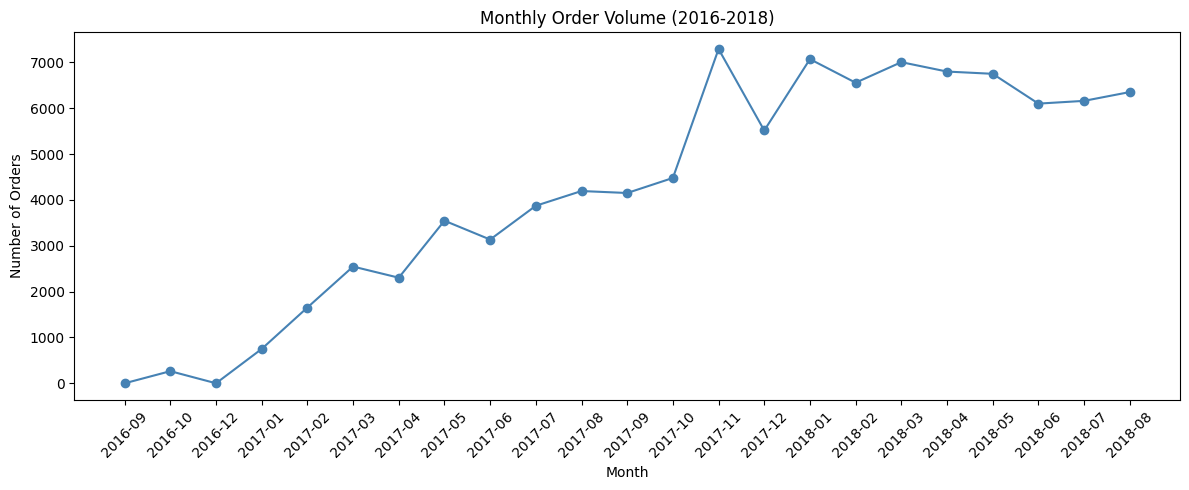

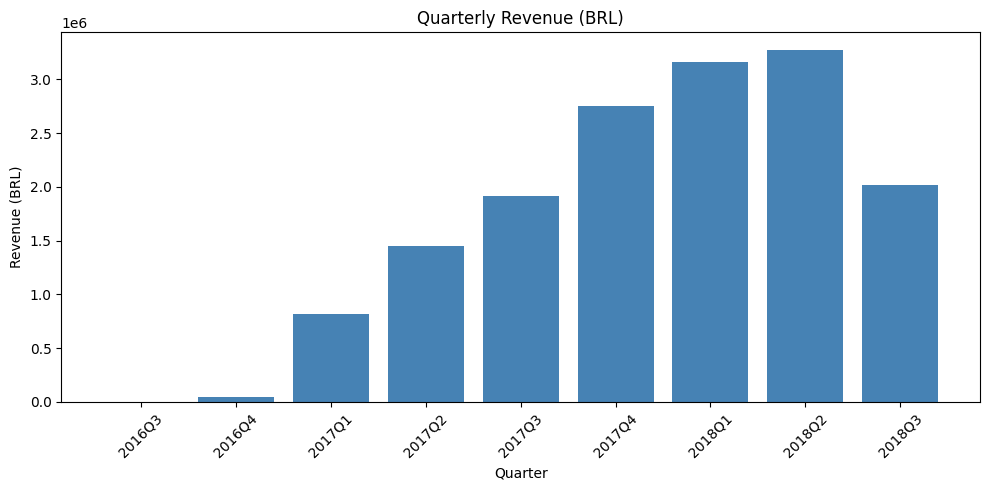

In [86]:
# Monthly order trend
plt.figure(figsize=(12, 5))
plt.plot(monthly['month'], monthly['num_orders'], marker='o', color='steelblue')
plt.title('Monthly Order Volume (2016-2018)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Quarterly revenue
plt.figure(figsize=(10, 5))
plt.bar(quarterly['quarter'], quarterly['total_revenue'], color='steelblue')
plt.title('Quarterly Revenue (BRL)')
plt.xlabel('Quarter')
plt.ylabel('Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The data shows strong positive growth from late 2016 to mid-2018. I can't give the exact year-on-year growth figures as I don't have all the quarters. There's a particularly noticeable increase around *November 2017*, coinciding with Brazil's *Black Friday* shopping event.


In [87]:
# Check if November 2017 spike aligns with Black Friday
# Black Friday 2017 was on November 24, 2017.

nov_2017 = master[
    (master['order_purchase_timestamp'].dt.year == 2017) &
    (master['order_purchase_timestamp'].dt.month == 11)
].drop_duplicates('order_id')

daily = nov_2017.groupby(nov_2017['order_purchase_timestamp'].dt.day)['order_id'].count()

print("Daily orders in November 2017:")
print(daily)
print(f"\nBlack Friday (Nov 24) orders: {daily.get(24, 0)}")
print(f"Average daily orders that month: {daily.mean():.0f}")

Daily orders in November 2017:
order_purchase_timestamp
1      108
2      117
3      138
4      106
5      137
6      182
7      154
8      169
9      182
10     159
11     152
12     170
13     197
14     184
15     176
16     219
17     185
18     141
19     157
20     219
21     222
22     190
23     268
24    1147
25     487
26     382
27     395
28     372
29     314
30     260
Name: order_id, dtype: int64

Black Friday (Nov 24) orders: 1147
Average daily orders that month: 243


To verify this, I checked daily orders for November 2017.
Black Friday (November 24) had 1,147 orders nearly 5x
the monthly daily average of 243. This confirms the spike
is directly caused by Black Friday, not just a general
monthly trend.

## BQ2: What is the best time to show advertising to customers?

Knowing customer ordering habits allows Olist to concentrate advertising budgets during peak windows without increasing the total spend.


In [88]:
# Orders by hour
hour_counts = master.drop_duplicates('order_id').groupby('purchase_hour')['order_id'].count().reset_index()
hour_counts.columns = ['hour', 'orders']

# Orders by day of week
day_counts = master.drop_duplicates('order_id').groupby('purchase_dayofweek')['order_id'].count().reset_index()
day_counts.columns = ['day', 'orders']

print(hour_counts)
print(day_counts)

    hour  orders
0      0    2321
1      1    1133
2      2     496
3      3     259
4      4     203
5      5     182
6      6     478
7      7    1199
8      8    2907
9      9    4647
10    10    5978
11    11    6385
12    12    5803
13    13    6309
14    14    6383
15    15    6249
16    16    6476
17    17    5963
18    18    5585
19    19    5801
20    20    6007
21    21    6040
22    22    5659
23    23    4015
         day  orders
0     Friday   13685
1     Monday   15701
2   Saturday   10555
3     Sunday   11635
4   Thursday   14323
5    Tuesday   15503
6  Wednesday   15076


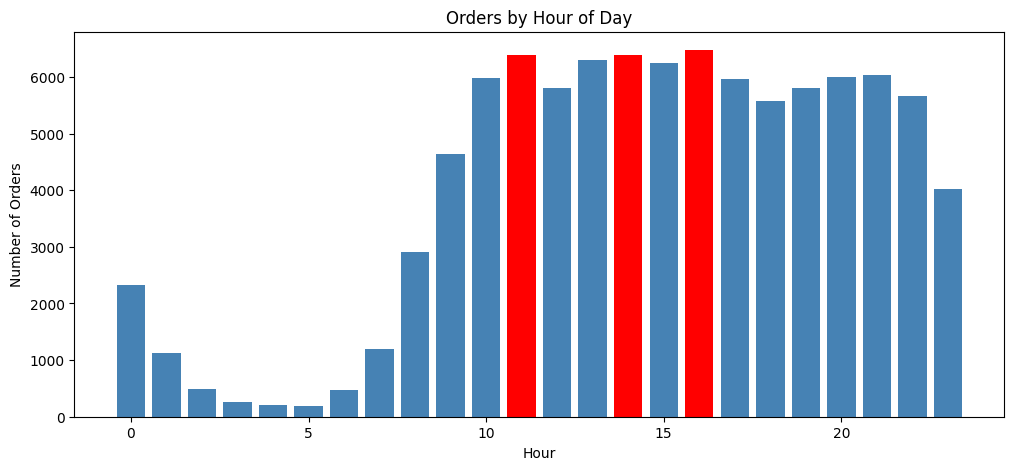

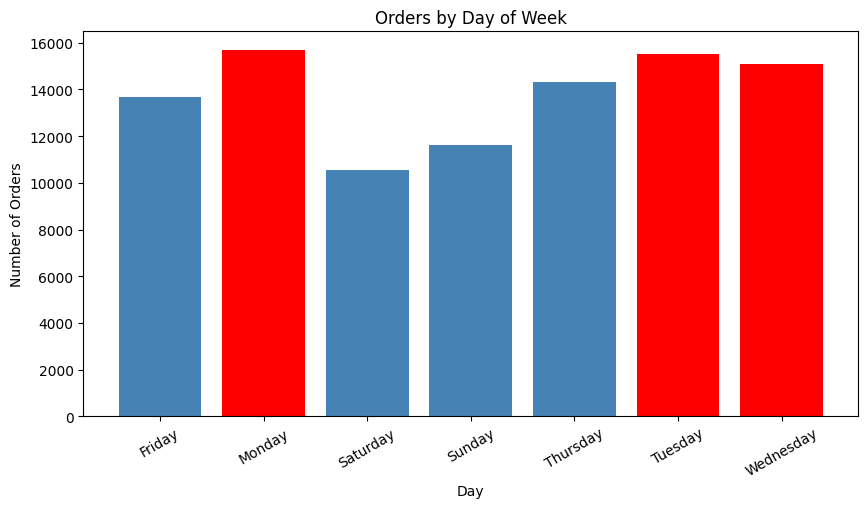

In [89]:
# Find top 3 hours and days
top3_hours = hour_counts.nlargest(3, 'orders')['hour'].tolist()
top3_days = day_counts.nlargest(3, 'orders')['day'].tolist()

# Color top 3 red, rest blue
# I found this coloring approach online, it checks each bar and assigns red if it'
hour_colors = ['red' if h in top3_hours else 'steelblue' for h in hour_counts['hour']]
day_colors = ['red' if d in top3_days else 'steelblue' for d in day_counts['day']]

# Orders by hour
plt.figure(figsize=(12, 5))
plt.bar(hour_counts['hour'], hour_counts['orders'], color=hour_colors)
plt.title('Orders by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.show()

# Orders by day of week
plt.figure(figsize=(10, 5))
plt.bar(day_counts['day'], day_counts['orders'], color=day_colors)
plt.title('Orders by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30)
plt.show()

I actually expected weekends to have more orders people have more free time. But the data showed the opposite. I see that most orders are placed during the daytime, between 10 am and 4 pm.


## BQ3: Which product categories contribute the most to revenue?

I was curious about which product categories Brazilians shop for the most. I had no prior knowledge of Brazilian consumer habits, so i wanted to let the data tell me.



In [90]:
# Revenue by category
cat_revenue = master.groupby('category_en')['total_payment'].sum().reset_index()
cat_revenue.columns = ['category', 'total_revenue']

# Number of orders by category
cat_orders = master.groupby('category_en')['order_id'].nunique().reset_index()
cat_orders.columns = ['category', 'num_orders']

# Merge and sort
cat_revenue = cat_revenue.merge(cat_orders, on='category')
cat_revenue = cat_revenue.sort_values('total_revenue', ascending=False).head(15)

print(cat_revenue.head(10))

                 category  total_revenue  num_orders
7          bed_bath_table     1723932.14        9272
43          health_beauty     1625923.50        8647
15  computers_accessories     1563315.62        6530
39        furniture_decor     1408110.04        6307
71          watches_gifts     1388699.25        5495
65         sports_leisure     1357249.46        7530
49             housewares     1072820.85        5743
5                    auto      835782.91        3810
42           garden_tools      813055.77        3448
20             cool_stuff      746763.39        3559


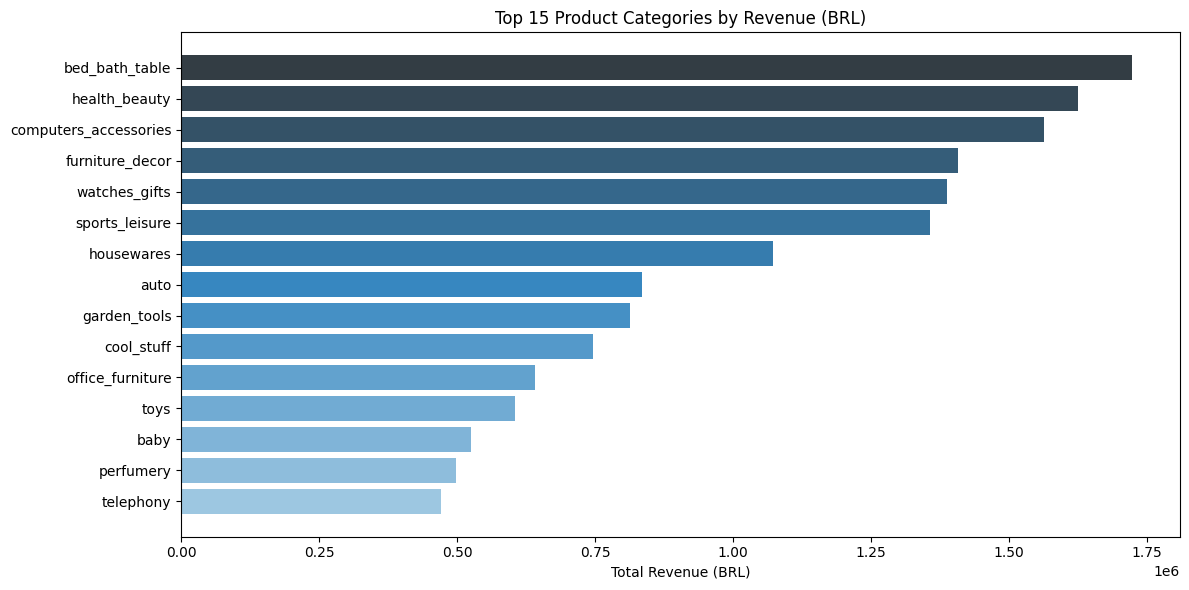

In [91]:
colors = sns.color_palette('Blues_d', 15)

plt.figure(figsize=(12, 6))
plt.barh(cat_revenue['category'][::-1], cat_revenue['total_revenue'][::-1], color=colors)
plt.title('Top 15 Product Categories by Revenue (BRL)')
plt.xlabel('Total Revenue (BRL)')
plt.tight_layout()
plt.show()

Revenue is calculated using total_payment (product price +
freight) rather than price alone, as this better reflects
actual income.

Categories such as *bed/bath/table, health & beauty, computers/accessories,* and *furniture* lead in total revenue.

 The *computers/accessories* category is one of the top three categories and includes  which may have low order volumes, but the high order value.

## BQ4: Does delivery delay affect customer review scores?

I was curious whether delivery time actually affects how customers rate their experience. It seemed obvious that late deliveries would get lower scores, but i wanted to see if the data confirms this and by how much.



In [92]:
delay_review = master.drop_duplicates('order_id')[['delay_days', 'review_score']].dropna()

# Split delay into categories
bins = [-np.inf, -14, -7, 0, 3, 7, np.inf]
labels = ['Very Early', 'Early', 'On Time', 'Slightly Late', 'Late', 'Very Late']
delay_review['delay_bin'] = pd.cut(delay_review['delay_days'], bins=bins, labels=labels)

# Count orders and average score per category
num_orders = delay_review.groupby('delay_bin', observed=True)['review_score'].count().reset_index()
num_orders.columns = ['delay_bin', 'num_orders']

avg_score = delay_review.groupby('delay_bin', observed=True)['review_score'].mean().reset_index()
avg_score.columns = ['delay_bin', 'rev_avg_score']

delay_summary = num_orders.merge(avg_score, on='delay_bin')

print(delay_summary)
print("Total orders:", delay_summary['num_orders'].sum())

       delay_bin  num_orders  rev_avg_score
0     Very Early       41861       4.324646
1          Early       33883       4.299442
2        On Time       13699       4.165487
3  Slightly Late        1852       3.291037
4           Late        1748       2.106407
5      Very Late        2781       1.696512
Total orders: 95824


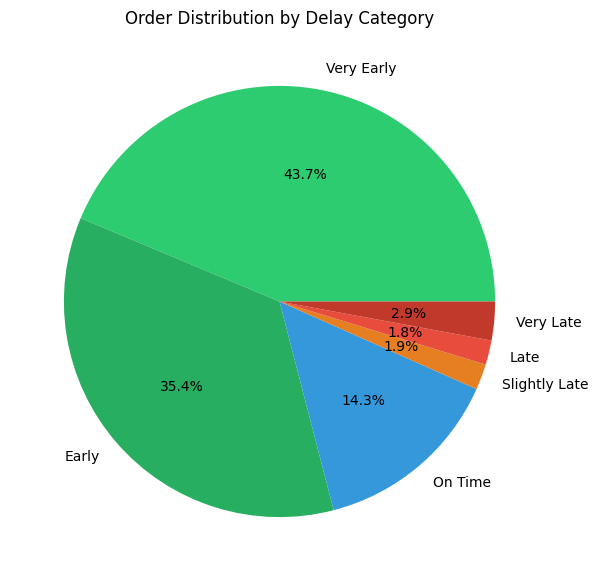

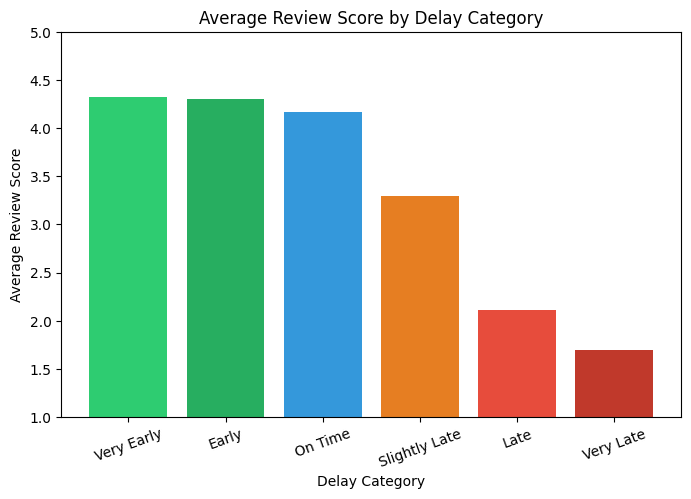

Correlation between delay and review score: -0.267


In [93]:
# Green for early, red for late
colors = ['#2ecc71', '#27ae60', '#3498db', '#e67e22', '#e74c3c', '#c0392b']

# Pie chart - order distribution
plt.figure(figsize=(7, 7))
plt.pie(delay_summary['num_orders'], labels=delay_summary['delay_bin'],
        autopct='%1.1f%%', colors=colors)
plt.title('Order Distribution by Delay Category')
plt.show()

# Bar chart - average review score
plt.figure(figsize=(8, 5))
plt.bar(delay_summary['delay_bin'], delay_summary['rev_avg_score'], color=colors)
plt.title('Average Review Score by Delay Category')
plt.xlabel('Delay Category')
plt.ylabel('Average Review Score')
plt.ylim(1, 5)
plt.xticks(rotation=20)
plt.show()

corr = delay_review['delay_days'].corr(delay_review['review_score'])
print("Correlation between delay and review score:", round(corr, 3))


The pie chart shows that 93% of orders are delivered earlier
than estimated or on time, which is impressive, repeat customer rate
remains very low (382 customers). But late deliveries receive dramatically lower scores  very late orders drop to around 2.5 out of 5.

## BQ5: Which cities and states generate the most orders?

Brazil is a huge country and i was curious whether the poorest or most remote regions would shop more online, maybe because they lack local stores. I wanted to see if geography plays a role in purchasing behaviour.


In [94]:
# Orders by state
state_orders = master.drop_duplicates('order_id').groupby('customer_state')['order_id'].count()
state_orders = state_orders.sort_values(ascending=False).reset_index()
state_orders.columns = ['state', 'num_orders']

# Revenue by state
state_revenue = master.drop_duplicates('order_id').groupby('customer_state')['total_payment'].sum()
state_revenue = state_revenue.sort_values(ascending=False).reset_index()
state_revenue.columns = ['state', 'total_revenue']

# Top 10 cities
city_orders = master.drop_duplicates('order_id').groupby('customer_city')['order_id'].count()
city_orders = city_orders.sort_values(ascending=False).head(10).reset_index()
city_orders.columns = ['city', 'num_orders']

print(state_orders.head(10))
print(state_revenue.head(10))
print(city_orders)

  state  num_orders
0    SP       40501
1    RJ       12350
2    MG       11354
3    RS        5345
4    PR        4923
5    SC        3546
6    BA        3256
7    DF        2080
8    ES        1995
9    GO        1957
  state  total_revenue
0    SP     5770266.19
1    RJ     2055690.45
2    MG     1819277.61
3    RS      861802.40
4    PR      781919.55
5    SC      595208.40
6    BA      591270.60
7    DF      346146.17
8    GO      334294.22
9    ES      317682.65
                    city  num_orders
0              sao paulo       15045
1         rio de janeiro        6601
2         belo horizonte        2697
3               brasilia        2071
4               curitiba        1489
5               campinas        1406
6           porto alegre        1342
7               salvador        1188
8              guarulhos        1144
9  sao bernardo do campo         911


In [95]:
#I'm trying to find which cities belong to which state so thati can use the same color in the visualization.
#Find which city in which state
city_state = master[['customer_city', 'customer_state']].drop_duplicates('customer_city')
city_state.columns = ['city', 'state']

city_orders = city_orders.merge(city_state, on='city', how='left')
print(city_orders)

                    city  num_orders state
0              sao paulo       15045    SP
1         rio de janeiro        6601    RJ
2         belo horizonte        2697    MG
3               brasilia        2071    DF
4               curitiba        1489    PR
5               campinas        1406    SP
6           porto alegre        1342    RS
7               salvador        1188    BA
8              guarulhos        1144    SP
9  sao bernardo do campo         911    SP


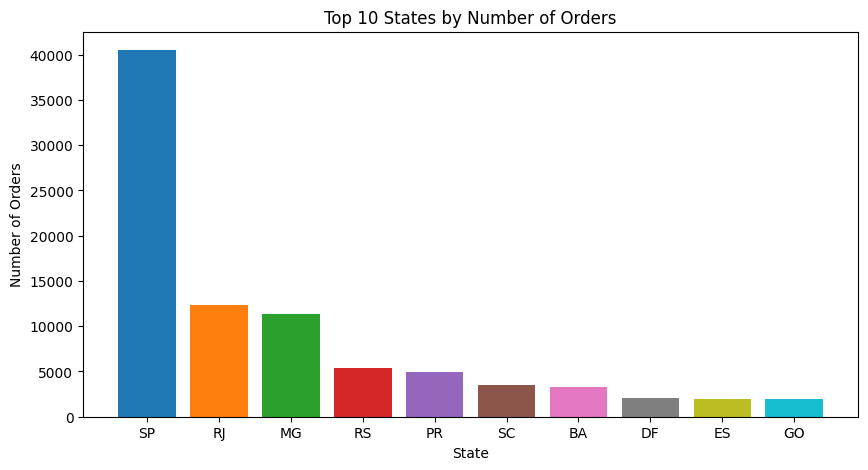

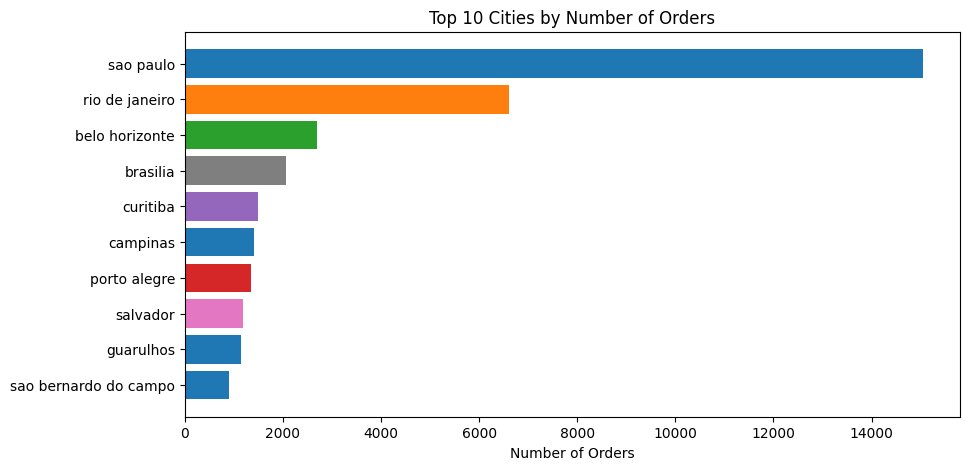

In [96]:
# Assign color to states
states = state_orders['state'].head(10).tolist()
colors = sns.color_palette('tab10', 10)
state_color = dict(zip(states, colors))

# Top 10 states graph
plt.figure(figsize=(10, 5))
plt.bar(state_orders['state'].head(10), state_orders['num_orders'].head(10),
        color=[state_color.get(s, 'grey') for s in state_orders['state'].head(10)])
plt.title('Top 10 States by Number of Orders')
plt.xlabel('State')
plt.ylabel('Number of Orders')
plt.show()

# Top 10 cities graph
plt.figure(figsize=(10, 5))
plt.barh(city_orders['city'][::-1], city_orders['num_orders'][::-1],
         color=[state_color.get(s, 'grey') for s in city_orders['state'][::-1]])
plt.title('Top 10 Cities by Number of Orders')
plt.xlabel('Number of Orders')
plt.show()

Colors represent the state each city belongs to cities with the same color are in the same state.  For example, Sao Paulo, Campinas and Guarulhos are all  in SP state (blue).

Being the most populous and wealthiest state in Brazil, Sao Paulo leads both the state and city rankings with 40,501 state level orders and 15,045 orders in the city alone.  SP state has 3 of the top 10 cities.


## BQ6: Which sellers generate high revenue but receive low review scores?

High sales don't always translate to high customer reviews. This can damage Olist's reputation and credibility. I'm investigating this with this question.

In [97]:
# Calculate seller performance
seller_revenue = master.groupby('seller_id')['total_payment'].sum().reset_index()
seller_revenue.columns = ['seller_id', 'total_revenue']

seller_review = master.groupby('seller_id')['review_score'].mean().reset_index()
seller_review.columns = ['seller_id', 'avg_review']

seller_orders = master.groupby('seller_id')['order_id'].nunique().reset_index()
seller_orders.columns = ['seller_id', 'num_orders']

# Merge all
seller_perf = seller_revenue.merge(seller_review, on='seller_id').merge(seller_orders, on='seller_id')

# Top 30 sellers by revenue
top30 = seller_perf.sort_values('total_revenue', ascending=False).head(30)

# Find risky sellers (review score below 3.5)
risky = top30[top30['avg_review'] < 3.5]

print("Risky sellers (review < 3.5):", len(risky))
print(risky.sort_values('avg_review'))

Risky sellers (review < 3.5): 2
                             seller_id  total_revenue  avg_review  num_orders
2073  b37c4c02bda3161a7546a4e6d222d5b2      145319.04    1.400000           4
1480  7c67e1448b00f6e969d365cea6b010ab      510915.44    3.354197         973


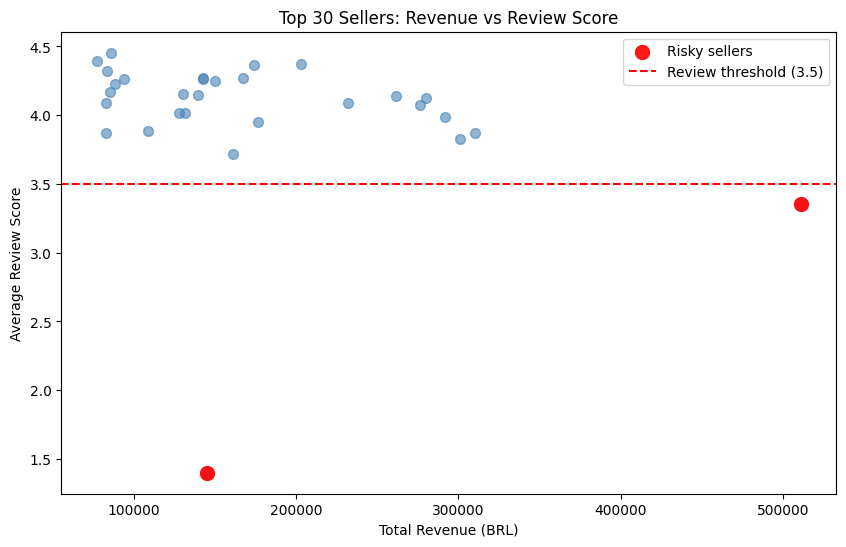

In [98]:
plt.figure(figsize=(10, 6))
plt.scatter(top30['total_revenue'], top30['avg_review'],
            color='steelblue', alpha=0.6, s=50)

# Highlight risky sellers in red
plt.scatter(risky['total_revenue'], risky['avg_review'],
            color='red', alpha=0.9, s=100, label='Risky sellers')

plt.axhline(y=3.5, color='red', linestyle='--', label='Review threshold (3.5)')
plt.title('Top 30 Sellers: Revenue vs Review Score')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Average Review Score')
plt.legend()
plt.show()

Among the top 30 highest revenue sellers, 3 have an average
review score below 3.5 (marked in red).

The most concerning case is the seller with 510,000 BRL
revenue and only 3.35 average score this seller generates
the highest revenue in the entire top 30 but has poor
customer satisfaction. These represent a significant risk; they bring in revenue short term, but at the cost of platform trust.

The seller with 1.4 average score has only 4 orders,
so this may not be reliable data.  Each order contained many items placed at the exact same second likely a bulk purchase, which may explain the low score.


#5. Conclusion

The three findings that surprised me most were: Black Friday causing a nearly 5x spike in daily orders, only 382 repeat customers out of 96,000+ orders, and the strong link between late delivery and low review scores.

These three are connected, if Olist reduces late deliveries, review scores improve, which likely increases retention. This should be the top priority.

## Strengths of This Analysis

- Rich multi-table dataset allowing cross-table analysis
- Derived features (delay_days, delivery_duration)
  revealed insights not visible in raw data
- Mix of visualizations makes findings accessible
  to non-technical stakeholders

##Limitations

- The dataset covers only 2016–2018; consumer behaviour and logistics infrastructure may have changed significantly since then.
- Product names are anonymised, limiting product-level analysis.

##Recommendations
- Concentrate advertising spend on weekday afternoons; launch a formal Black
Friday campaign no later than mid-October and prepare logistics capacity 6 weeks before Black Friday every year.

- Introduce a seller performance rating system that combines revenue, review scores.The sellers should receive warnings and suggestions for improving their ratings.Persistent underperformers should face listing restrictions.

- Invest in the top-revenue categories to increase competition, improve selection, and lower prices.

- Focus on eliminating very late deliveries this is the biggest driver of low scores. Open a regional warehouse in SP would significantly reduce delivery times and costs for the majority of orders.

##References
- Olist (2018). *Brazilian E-Commerce Public Dataset by Olist*. Kaggle. https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce/data












In [107]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/.ipynb"M504_Final_Assignment_Olist

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/M504_Final_Assignment_Olist.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Writing 887881 bytes to /content/drive/MyDrive/Colab Notebooks/M504_Final_Assignment_Olist.html


In [108]:
import json

path = '/content/drive/MyDrive/Colab Notebooks/M504_Final_Assignment_Olist.ipynb'

with open(path, 'r') as f:
    notebook = json.load(f)

total_chars = 0
for cell in notebook['cells']:
    for line in cell['source']:
        total_chars += len(line)

print(f"Total characters: {total_chars:,}")

Total characters: 23,946
